In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import urllib.request
import zipfile

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
print("Downloading dataset...")

url = "http://thinknook.com/wp-content/uploads/2012/09/Sentiment-Analysis-Dataset.zip"
file_name = "sentiment140.zip"

urllib.request.urlretrieve(url, file_name)

with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall("sentiment_data")

print("Download Complete!")

Download Complete!


In [ ]:
df = pd.read_csv(
    "sentiment_data/Sentiment Analysis Dataset.csv",
    encoding="latin-1",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,ï»¿ItemID,Sentiment,SentimentSource,SentimentText
0,1,0,Sentiment140,is so sad for my APL frie...
1,2,0,Sentiment140,I missed the New Moon trail...
2,3,1,Sentiment140,omg its already 7:30 :O
3,4,0,Sentiment140,.. Omgaga. Im sooo im gunna CRy. I'...
4,5,0,Sentiment140,i think mi bf is cheating on me!!! ...


In [ ]:
print(df.columns)

Index(['ï»¿ItemID', 'Sentiment', 'SentimentSource', 'SentimentText'], dtype='object')


In [ ]:
df = df[['Sentiment', 'SentimentText']]
df.columns = ['sentiment', 'text']

df.head()

,sentiment,text
0,0,is so sad for my APL frie...
1,0,I missed the New Moon trail...
2,1,omg its already 7:30 :O
3,0,.. Omgaga. Im sooo im gunna CRy. I'...
4,0,i think mi bf is cheating on me!!! ...


In [ ]:
df['sentiment'] = df['sentiment'].astype(int)

print(df['sentiment'].value_counts())

sentiment
1    790171
0    788430
Name: count, dtype: int64


/tmp/ipykernel_1059/3751688905.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['sentiment'].astype(int)


In [ ]:
# Reduce dataset size for faster training
df = df.sample(20000, random_state=42)

print("New Dataset Shape:", df.shape)
print(df.head())

New Dataset Shape: (20000, 2)
         sentiment                                               text
47319            1  @aravindkumar my absolute faith rite now comes...
277622           1  @Lenqa teraz to az thak nevidno.. konce mam es...
1057407          1  Man! StarBucks was a Mission! Ugh! But it was ...
703893           0  good mu'fuckin weekend. gotta do this again......
957066           0  It is with extreme sadness that I removed &quo...


In [ ]:
# Create stopwords set
stop_words = set(stopwords.words('english'))

# Define cleaning function
def clean_text(text):
    text = str(text).lower()  # convert to lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    words = text.split()  # tokenize
    words = [w for w in words if w not in stop_words]  # remove stopwords
    return " ".join(words)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Show result
df[['text', 'clean_text']].head()

,text,clean_text
47319,@aravindkumar my absolute faith rite now comes...,aravindkumar absolute faith rite comes found a...
277622,@Lenqa teraz to az thak nevidno.. konce mam es...,lenqa teraz az thak nevidno konce mam este tha...
1057407,Man! StarBucks was a Mission! Ugh! But it was ...,man starbucks mission ugh worth mmm soo good
703893,good mu'fuckin weekend. gotta do this again......,good mufuckin weekend gotta againnex weekend k...
957066,It is with extreme sadness that I removed &quo...,extreme sadness removed quotelestoqueorgquot w...


In [ ]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=3000)

# Convert text into numerical features
X = tfidf.fit_transform(df['clean_text'])

# Target variable
y = df['sentiment']

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (20000, 3000)


In [ ]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16000, 3000)
Testing Data Shape: (4000, 3000)


In [ ]:
# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Detailed performance report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.72725

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.69      0.72      2002
           1       0.71      0.77      0.74      1998

    accuracy                           0.73      4000
   macro avg       0.73      0.73      0.73      4000
weighted avg       0.73      0.73      0.73      4000



In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [ ]:
# Logistic Regression predictions
y_pred_lr = model.predict(X_test)

# SVM predictions
y_pred_svm = svm_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.72725
SVM Accuracy: 0.7075


In [ ]:
print("\nLogistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nSVM Report:\n")
print(classification_report(y_test, y_pred_svm))


Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.75      0.69      0.72      2002
           1       0.71      0.77      0.74      1998

    accuracy                           0.73      4000
   macro avg       0.73      0.73      0.73      4000
weighted avg       0.73      0.73      0.73      4000


SVM Report:

              precision    recall  f1-score   support

           0       0.72      0.67      0.70      2002
           1       0.69      0.74      0.72      1998

    accuracy                           0.71      4000
   macro avg       0.71      0.71      0.71      4000
weighted avg       0.71      0.71      0.71      4000



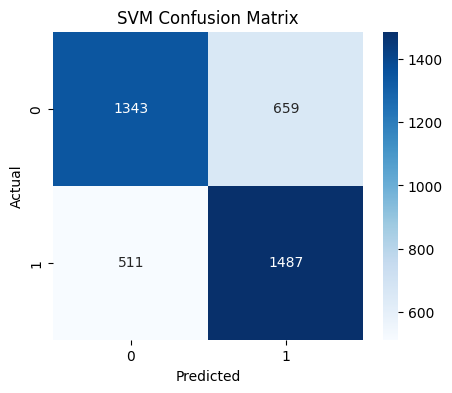

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
def predict_sentiment(text):
    text = clean_text(text)
    vector = tfidf.transform([text])
    prediction = svm_model.predict(vector)

    if prediction[0] == 0:
        return "Negative"
    else:
        return "Positive"

print(predict_sentiment("I love this product!"))
print(predict_sentiment("This is terrible service."))

Positive
Negative
